# XGBoost with Optuna Hyperparameter Tuning

This notebook trains an XGBoost model with:
- Custom data preprocessing
- Feature engineering
- Optuna hyperparameter optimization
- Model evaluation and predictions

XGBoost advantages:
- High performance and speed
- Regularization to prevent overfitting
- Handles missing values

**Note for macOS users:** XGBoost requires OpenMP. If you encounter import errors, run:
```bash
brew install libomp
```

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from xgboost import XGBClassifier
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

/Users/aaryan/Desktop/ML_Project_2/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Data

In [2]:
# Load training and test data
train_df = pd.read_csv('../dataset/train_dropped_column.csv')
test_df = pd.read_csv('../dataset/test_dropped_column.csv')

print(f"Training data shape: {train_df.shape}")
print(f"Test data shape: {test_df.shape}")
print(f"\nTarget distribution:")
print(train_df['retention_status'].value_counts())
print(f"\nClass balance: {train_df['retention_status'].value_counts(normalize=True)}")

Training data shape: (59608, 23)
Test data shape: (14900, 22)

Target distribution:
retention_status
Stayed    31264
Left      28344
Name: count, dtype: int64

Class balance: retention_status
Stayed    0.524493
Left      0.475507
Name: proportion, dtype: float64


## 2. Data Preprocessing & Feature Engineering

In [3]:
def preprocess_and_engineer_features(df, is_train=True):
    """
    Preprocess data and engineer features for XGBoost
    """
    df = df.copy()
    
    # Save founder_id for later
    founder_ids = df['founder_id'].copy()
    
    # Drop founder_id as it's not a feature
    df = df.drop('founder_id', axis=1)
    
    # Separate target if training data
    if is_train and 'retention_status' in df.columns:
        target = df['retention_status'].copy()
        df = df.drop('retention_status', axis=1)
    else:
        target = None
    
    # --- Feature Engineering ---
    
    # 1. Revenue features
    df['revenue_per_year'] = df['monthly_revenue_generated'] / (df['years_with_startup'] + 1)
    df['log_revenue'] = np.log1p(df['monthly_revenue_generated'])
    df['sqrt_revenue'] = np.sqrt(df['monthly_revenue_generated'])
    df['revenue_squared'] = df['monthly_revenue_generated'] ** 2
    
    # 2. Age-related features
    df['age_when_joined'] = df['founder_age'] - df['years_with_startup']
    df['is_young_founder'] = (df['founder_age'] < 30).astype(int)
    df['is_middle_age_founder'] = ((df['founder_age'] >= 30) & (df['founder_age'] <= 45)).astype(int)
    df['is_senior_founder'] = (df['founder_age'] > 50).astype(int)
    df['age_squared'] = df['founder_age'] ** 2
    
    # 3. Experience and tenure features
    df['experience_ratio'] = df['years_with_startup'] / (df['founder_age'] + 1)
    df['is_new_founder'] = (df['years_with_startup'] <= 2).astype(int)
    df['is_veteran_founder'] = (df['years_with_startup'] > 15).astype(int)
    df['tenure_squared'] = df['years_with_startup'] ** 2
    
    # 4. Performance scores (ordinal encoding)
    performance_mapping = {'Low': 1, 'Below Average': 2, 'Average': 3, 'High': 4}
    satisfaction_mapping = {'Low': 1, 'Medium': 2, 'High': 3, 'Very High': 4}
    balance_mapping = {'Poor': 1, 'Fair': 2, 'Good': 3, 'Excellent': 4}
    reputation_mapping = {'Poor': 1, 'Fair': 2, 'Good': 3, 'Excellent': 4}
    visibility_mapping = {'Low': 1, 'Medium': 2, 'High': 3, 'Very High': 4}
    
    df['performance_score'] = df['startup_performance_rating'].map(performance_mapping)
    df['satisfaction_score'] = df['venture_satisfaction'].map(satisfaction_mapping)
    df['balance_score'] = df['work_life_balance_rating'].map(balance_mapping)
    df['reputation_score'] = df['startup_reputation'].map(reputation_mapping)
    df['visibility_score'] = df['founder_visibility'].map(visibility_mapping)
    
    # 5. Composite scores
    df['overall_satisfaction'] = (df['performance_score'] + df['satisfaction_score'] + df['balance_score']) / 3
    df['performance_satisfaction_product'] = df['performance_score'] * df['satisfaction_score']
    df['balance_satisfaction_product'] = df['balance_score'] * df['satisfaction_score']
    
    # 6. Work-life indicators
    df['overtime_binary'] = (df['working_overtime'] == 'Yes').astype(int)
    df['poor_balance_overtime'] = ((df['working_overtime'] == 'Yes') & (df['balance_score'] <= 2)).astype(int)
    df['good_balance_no_overtime'] = ((df['working_overtime'] == 'No') & (df['balance_score'] >= 3)).astype(int)
    df['overtime_tenure_interaction'] = df['overtime_binary'] * df['years_with_startup']
    
    # 7. Leadership and funding features
    df['has_led_funding'] = (df['funding_rounds_led'] > 0).astype(int)
    df['funding_experience'] = df['funding_rounds_led'] * df['years_with_startup']
    df['funding_per_year'] = df['funding_rounds_led'] / (df['years_with_startup'] + 1)
    df['high_funding_rounds'] = (df['funding_rounds_led'] >= 2).astype(int)
    
    # 8. Location features
    df['near_investor_hub'] = (df['distance_from_investor_hub'] < 30).astype(int)
    df['very_far_from_hub'] = (df['distance_from_investor_hub'] > 70).astype(int)
    df['log_distance'] = np.log1p(df['distance_from_investor_hub'])
    df['revenue_distance_ratio'] = df['monthly_revenue_generated'] / (df['distance_from_investor_hub'] + 1)
    
    # 9. Education features
    education_order = {'High School': 1, 'Associate Degree': 2, 'Bachelor\'s Degree': 3, 
                      'Master\'s Degree': 4, 'PhD': 5}
    df['education_level'] = df['education_background'].map(education_order)
    df['high_education'] = (df['education_level'] >= 4).astype(int)
    
    # 10. Family features
    df['has_dependents'] = (df['num_dependents'] > 0).astype(int)
    df['many_dependents'] = (df['num_dependents'] > 3).astype(int)
    df['family_size'] = df['num_dependents'] + 1
    df['dependents_age_ratio'] = df['num_dependents'] / (df['founder_age'] + 1)
    
    # 11. Team size features
    team_size_mapping = {'Small': 1, 'Medium': 2, 'Large': 3}
    df['team_size_numeric'] = df['team_size_category'].map(team_size_mapping)
    df['large_team'] = (df['team_size_numeric'] == 3).astype(int)
    
    # 12. Startup stage features
    stage_mapping = {'Entry': 1, 'Mid': 2, 'Senior': 3}
    df['stage_numeric'] = df['startup_stage'].map(stage_mapping)
    df['senior_stage'] = (df['stage_numeric'] == 3).astype(int)
    
    # 13. Binary features
    df['remote_binary'] = (df['remote_operations'] == 'Yes').astype(int)
    df['leadership_binary'] = (df['leadership_scope'] == 'Yes').astype(int)
    df['innovation_binary'] = (df['innovation_support'] == 'Yes').astype(int)
    
    # 14. Interaction features
    df['remote_innovation'] = df['remote_binary'] * df['innovation_binary']
    df['leadership_innovation'] = df['leadership_binary'] * df['innovation_binary']
    df['team_reputation'] = df['team_size_numeric'] * df['reputation_score']
    df['visibility_reputation'] = df['visibility_score'] * df['reputation_score']
    df['high_performer_satisfied'] = ((df['performance_score'] >= 3) & (df['satisfaction_score'] >= 3)).astype(int)
    df['low_performer_unsatisfied'] = ((df['performance_score'] <= 2) & (df['satisfaction_score'] <= 2)).astype(int)
    
    # 15. Gender and role encoding
    df['is_male'] = (df['founder_gender'] == 'Male').astype(int)
    
    # Role encoding
    role_dummies = pd.get_dummies(df['founder_role'], prefix='role')
    df = pd.concat([df, role_dummies], axis=1)
    
    # Personal status encoding
    status_dummies = pd.get_dummies(df['personal_status'], prefix='status')
    df = pd.concat([df, status_dummies], axis=1)
    
    # Drop original categorical columns
    cols_to_drop = ['founder_gender', 'founder_role', 'work_life_balance_rating', 
                    'venture_satisfaction', 'startup_performance_rating', 'working_overtime',
                    'education_background', 'personal_status', 'startup_stage',
                    'team_size_category', 'remote_operations', 'leadership_scope',
                    'innovation_support', 'startup_reputation', 'founder_visibility']
    df = df.drop(columns=cols_to_drop, errors='ignore')
    
    # Handle any remaining missing values
    df = df.fillna(df.median(numeric_only=True))
    
    return df, target, founder_ids

# Preprocess data
X_train, y_train, train_ids = preprocess_and_engineer_features(train_df, is_train=True)
X_test, _, test_ids = preprocess_and_engineer_features(test_df, is_train=False)

# Encode target variable
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)

print(f"\nPreprocessed training features shape: {X_train.shape}")
print(f"Preprocessed test features shape: {X_test.shape}")
print(f"\nSample features: {X_train.columns.tolist()[:15]}...")  # Show first 15


Preprocessed training features shape: (59608, 67)
Preprocessed test features shape: (14900, 67)

Sample features: ['founder_age', 'years_with_startup', 'monthly_revenue_generated', 'funding_rounds_led', 'distance_from_investor_hub', 'num_dependents', 'revenue_per_year', 'log_revenue', 'sqrt_revenue', 'revenue_squared', 'age_when_joined', 'is_young_founder', 'is_middle_age_founder', 'is_senior_founder', 'age_squared']...


In [4]:
# Align test set columns with training set
missing_cols = set(X_train.columns) - set(X_test.columns)
for col in missing_cols:
    X_test[col] = 0

extra_cols = set(X_test.columns) - set(X_train.columns)
X_test = X_test.drop(columns=list(extra_cols))

# Ensure same column order
X_test = X_test[X_train.columns]

print(f"Aligned test features shape: {X_test.shape}")

Aligned test features shape: (14900, 67)


## 3. Train-Validation Split

In [5]:
# Split data for validation
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train, y_train_encoded, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train_encoded
)

print(f"Training set: {X_train_split.shape}")
print(f"Validation set: {X_val_split.shape}")

Training set: (47686, 67)
Validation set: (11922, 67)


## 4. Optuna Hyperparameter Tuning

In [6]:
def objective(trial):
    """
    Objective function for Optuna optimization
    """
    # Suggest hyperparameters
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 5),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1, 10),
        'random_state': RANDOM_STATE,
        'tree_method': 'hist',
        'verbosity': 0,
        'n_jobs': -1
    }
    
    # Train model with cross-validation
    model = XGBClassifier(**params)
    
    # Use stratified k-fold cross-validation
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X_train_split, y_train_split, cv=cv, 
                             scoring='accuracy', n_jobs=-1)
    
    return scores.mean()

# Create Optuna study
print("Starting Optuna hyperparameter optimization...\n")
print("This may take several minutes...\n")
study = optuna.create_study(direction='maximize', study_name='xgboost_optimization')
study.optimize(objective, n_trials=40, show_progress_bar=True)

print(f"\n{'='*50}")
print("Optimization Complete!")
print(f"{'='*50}")
print(f"Best accuracy: {study.best_value:.4f}")
print(f"\nBest hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

[I 2025-11-26 20:56:44,895] A new study created in memory with name: xgboost_optimization


Starting Optuna hyperparameter optimization...

This may take several minutes...



Best trial: 0. Best value: 0.748941:   2%|▎         | 1/40 [00:04<02:50,  4.37s/it]

[I 2025-11-26 20:56:49,273] Trial 0 finished with value: 0.7489409825921546 and parameters: {'n_estimators': 855, 'max_depth': 9, 'learning_rate': 0.18247582685005465, 'subsample': 0.8905634333068255, 'colsample_bytree': 0.7116372268916668, 'colsample_bylevel': 0.7797921415763238, 'min_child_weight': 7, 'gamma': 2.3374982655822016, 'reg_alpha': 4.979582796491395, 'reg_lambda': 3.7366990755143927, 'scale_pos_weight': 1.0160909583814646}. Best is trial 0 with value: 0.7489409825921546.


Best trial: 0. Best value: 0.748941:   5%|▌         | 2/40 [00:26<09:18, 14.69s/it]

...

[I 2025-11-26 21:01:21,953] Trial 37 finished with value: 0.7227907502361871 and parameters: {'n_estimators': 985, 'max_depth': 7, 'learning_rate': 0.10170248297407553, 'subsample': 0.602307375305455, 'colsample_bytree': 0.9495807028606696, 'colsample_bylevel': 0.736233197170725, 'min_child_weight': 2, 'gamma': 2.4653808011604808, 'reg_alpha': 4.651757391857201, 'reg_lambda': 0.6292407233503234, 'scale_pos_weight': 2.5594160739330727}. Best is trial 15 with value: 0.7509750583891236.


Best trial: 15. Best value: 0.750975:  98%|█████████▊| 39/40 [04:46<00:07,  7.89s/it]

[I 2025-11-26 21:01:31,069] Trial 38 finished with value: 0.7442226258453882 and parameters: {'n_estimators': 1265, 'max_depth': 9, 'learning_rate': 0.04634969022684917, 'subsample': 0.7314198084119404, 'colsample_bytree': 0.7440028558154691, 'colsample_bylevel': 0.6662948739360911, 'min_child_weight': 1, 'gamma': 2.9705075385396977, 'reg_alpha': 4.227494832758997, 'reg_lambda': 1.156004957953669, 'scale_pos_weight': 1.4753428109302331}. Best is trial 15 with value: 0.7509750583891236.


Best trial: 15. Best value: 0.750975: 100%|██████████| 40/40 [04:50<00:00,  7.26s/it]

[I 2025-11-26 21:01:35,221] Trial 39 finished with value: 0.7116134975906885 and parameters: {'n_estimators': 863, 'max_depth': 3, 'learning_rate': 0.12615028694431996, 'subsample': 0.8097685608340168, 'colsample_bytree': 0.8731368700277934, 'colsample_bylevel': 0.7756707342739626, 'min_child_weight': 4, 'gamma': 3.7296983241471553, 'reg_alpha': 3.7848566444776357, 'reg_lambda': 0.03083645940024682, 'scale_pos_weight': 2.814418164575139}. Best is trial 15 with value: 0.7509750583891236.

Optimization Complete!
Best accuracy: 0.7510

Best hyperparameters:
  n_estimators: 946
  max_depth: 10
  learning_rate: 0.060245518647664295
  subsample: 0.9336426502514603
  colsample_bytree: 0.7281167002457108
  colsample_bylevel: 0.9925894088012811
  min_child_weight: 1
  gamma: 4.197822795628047
  reg_alpha: 4.40283179709386
  reg_lambda: 4.569006326275219
  scale_pos_weight: 1.0220614803362895


In [8]:
%pip install plotly kaleido

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Visualize optimization history
try:
    fig = plot_optimization_history(study)
    fig.show()
    
    # Visualize parameter importances
    fig = plot_param_importances(study)
    fig.show()
except ImportError:
    print("Plotly not installed. Skipping visualizations.")
    print("To install: pip install plotly kaleido")

## 5. Train Final Model with Best Parameters

In [11]:
# Train final model with best parameters
best_params = study.best_params.copy()
best_params['random_state'] = RANDOM_STATE
best_params['tree_method'] = 'hist'
best_params['n_jobs'] = -1
best_params['early_stopping_rounds'] = 50  # Add to model params

final_model = XGBClassifier(**best_params)
final_model.fit(
    X_train_split, y_train_split,
    eval_set=[(X_val_split, y_val_split)],
    verbose=50  # Print progress every 50 iterations
)

print("\nFinal model trained successfully!")
print(f"Best iteration: {final_model.best_iteration}")

[0]	validation_0-logloss:0.67521
[50]	validation_0-logloss:0.50150
[50]	validation_0-logloss:0.50150
[100]	validation_0-logloss:0.48975
[100]	validation_0-logloss:0.48975
[150]	validation_0-logloss:0.48780
[150]	validation_0-logloss:0.48780
[200]	validation_0-logloss:0.48731
[200]	validation_0-logloss:0.48731
[250]	validation_0-logloss:0.48714
[250]	validation_0-logloss:0.48714
[300]	validation_0-logloss:0.48710
[300]	validation_0-logloss:0.48710
[350]	validation_0-logloss:0.48708
[350]	validation_0-logloss:0.48708
[400]	validation_0-logloss:0.48705
[400]	validation_0-logloss:0.48705
[450]	validation_0-logloss:0.48703
[450]	validation_0-logloss:0.48703
[500]	validation_0-logloss:0.48703
[500]	validation_0-logloss:0.48703
[550]	validation_0-logloss:0.48704
[550]	validation_0-logloss:0.48704
[574]	validation_0-logloss:0.48703
[574]	validation_0-logloss:0.48703

Final model trained successfully!
Best iteration: 524

Final model trained successfully!
Best iteration: 524


## 6. Model Evaluation

In [12]:
# Make predictions on validation set
y_val_pred = final_model.predict(X_val_split)
y_val_pred_proba = final_model.predict_proba(X_val_split)

# Calculate metrics
val_accuracy = accuracy_score(y_val_split, y_val_pred)
val_roc_auc = roc_auc_score(y_val_split, y_val_pred_proba[:, 1])

print(f"{'='*50}")
print("Validation Set Performance")
print(f"{'='*50}")
print(f"Accuracy: {val_accuracy:.4f}")
print(f"ROC AUC Score: {val_roc_auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_val_split, y_val_pred, target_names=le.classes_))

Validation Set Performance
Accuracy: 0.7510
ROC AUC Score: 0.8404

Classification Report:
              precision    recall  f1-score   support

        Left       0.75      0.72      0.73      5669
      Stayed       0.76      0.78      0.77      6253

    accuracy                           0.75     11922
   macro avg       0.75      0.75      0.75     11922
weighted avg       0.75      0.75      0.75     11922



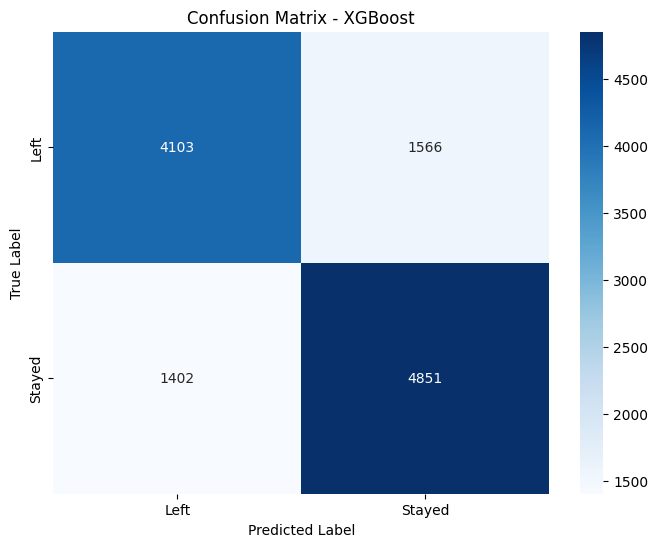

In [13]:
# Confusion Matrix
cm = confusion_matrix(y_val_split, y_val_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - XGBoost')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

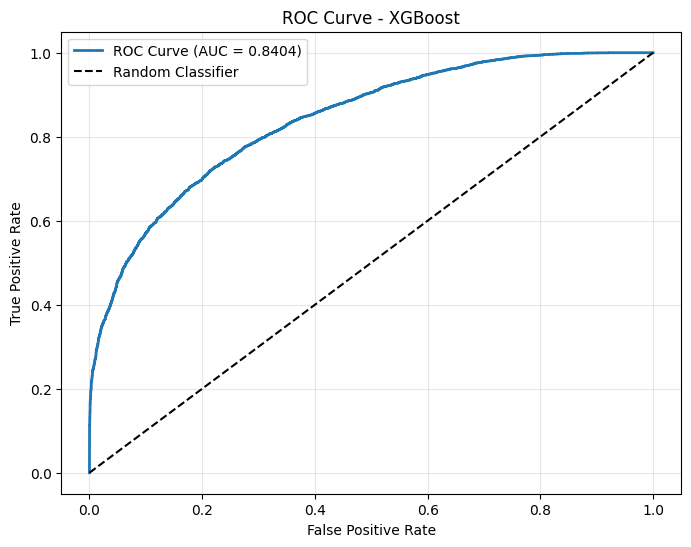

In [14]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_val_split, y_val_pred_proba[:, 1])
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {val_roc_auc:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

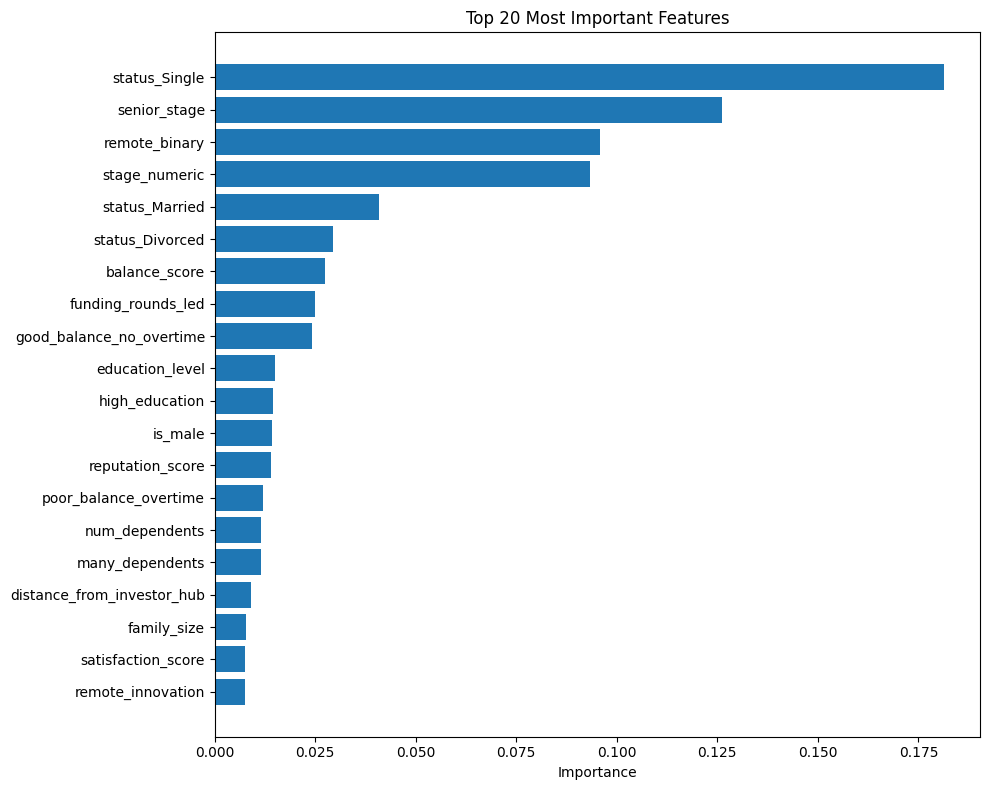


Top 20 Most Important Features:
                   feature  importance
             status_Single    0.181250
              senior_stage    0.126142
             remote_binary    0.095880
             stage_numeric    0.093362
            status_Married    0.040880
           status_Divorced    0.029431
             balance_score    0.027375
        funding_rounds_led    0.024890
  good_balance_no_overtime    0.024166
           education_level    0.015083
            high_education    0.014399
                   is_male    0.014217
          reputation_score    0.013918
     poor_balance_overtime    0.011958
            num_dependents    0.011630
           many_dependents    0.011475
distance_from_investor_hub    0.009073
               family_size    0.007785
        satisfaction_score    0.007514
         remote_innovation    0.007441


In [15]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Importance')
plt.title('Top 20 Most Important Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 20 Most Important Features:")
print(feature_importance.to_string(index=False))

## 7. Retrain on Full Training Data

In [20]:
# Retrain on full training data for final predictions
print("Retraining model on full training data...\n")

# Create a copy of best_params without early_stopping_rounds for final training
final_params = best_params.copy()
final_params.pop('early_stopping_rounds', None)  # Remove early stopping for final training

final_model_full = XGBClassifier(**final_params)
final_model_full.fit(X_train, y_train_encoded, verbose=50)  # Print progress every 50 iterations
print("\nModel retrained successfully!")

Retraining model on full training data...


Model retrained successfully!

Model retrained successfully!


## 8. Generate Test Predictions

In [21]:
# Make predictions on test set
y_test_pred = final_model_full.predict(X_test)
y_test_pred_proba = final_model_full.predict_proba(X_test)

# Convert predictions back to original labels
y_test_pred_labels = le.inverse_transform(y_test_pred)

print(f"Test predictions generated!")
print(f"\nPrediction distribution:")
print(pd.Series(y_test_pred_labels).value_counts())

Test predictions generated!

Prediction distribution:
Stayed    7968
Left      6932
Name: count, dtype: int64


## 9. Save Predictions

In [22]:
# Create submission file with probabilities
submission_probs = pd.DataFrame({
    'founder_id': test_ids,
    'retention_status': y_test_pred_labels,
    'probability_Left': y_test_pred_proba[:, 0],
    'probability_Stayed': y_test_pred_proba[:, 1]
})

submission_probs.to_csv('xgboost_predictions_with_probs.csv', index=False)
print("Predictions with probabilities saved to 'xgboost_predictions_with_probs.csv'")

# Create standard submission file
submission = pd.DataFrame({
    'founder_id': test_ids,
    'retention_status': y_test_pred_labels
})

submission.to_csv('submission_xgboost.csv', index=False)
print("Submission file saved to 'submission_xgboost.csv'")

print("\nFirst few predictions:")
print(submission.head(10))

Predictions with probabilities saved to 'xgboost_predictions_with_probs.csv'
Submission file saved to 'submission_xgboost.csv'

First few predictions:
   founder_id retention_status
0       52685           Stayed
1       30585             Left
2       54656           Stayed
3       33442             Left
4       15667           Stayed
5        3496           Stayed
6       46775             Left
7       72645             Left
8        4941           Stayed
9       65181             Left


## 10. Model Summary

In [23]:
# Save model
final_model_full.save_model('xgboost_model.json')
print("Model saved to 'xgboost_model.json'")

# Save model summary
summary = f"""
{'='*60}
XGBOOST MODEL SUMMARY
{'='*60}

Dataset Information:
- Training samples: {len(X_train)}
- Test samples: {len(X_test)}
- Number of features: {X_train.shape[1]}

Best Hyperparameters:
{chr(10).join(f'- {k}: {v}' for k, v in best_params.items())}

Validation Performance:
- Accuracy: {val_accuracy:.4f}
- ROC AUC: {val_roc_auc:.4f}
- Best Iteration: {final_model.best_iteration}

Feature Engineering Applied:
- Revenue features (per year, log, sqrt, squared)
- Age-related features (when joined, age groups, squared)
- Experience and tenure features (ratios, indicators, squared)
- Performance scores (ordinal encoding)
- Composite scores (satisfaction, performance products)
- Work-life balance indicators
- Leadership and funding metrics
- Location features (distance ratios, categories)
- Education level encoding
- Family features (dependents, family size)
- Team size and startup stage encoding
- Binary feature encoding
- Interaction features (remote, innovation, leadership)
- Gender and role encoding

Top 5 Most Important Features:
{chr(10).join(f'{i+1}. {row["feature"]}: {row["importance"]:.4f}' for i, row in feature_importance.head(5).iterrows())}

Preprocessing Steps:
1. Handled missing values with median imputation
2. Ordinal encoding for ordinal categorical variables
3. One-hot encoding for nominal categorical variables
4. Created polynomial and interaction features
5. Log and sqrt transformations for skewed features

Optuna Optimization:
- Number of trials: 40
- Cross-validation folds: 3
- Best CV score: {study.best_value:.4f}

Output Files:
- xgboost_predictions_with_probs.csv
- submission_xgboost.csv
- xgboost_model.json
{'='*60}
"""

print(summary)

with open('xgboost_summary.txt', 'w') as f:
    f.write(summary)

print("\nModel summary saved to 'xgboost_summary.txt'")

Model saved to 'xgboost_model.json'

XGBOOST MODEL SUMMARY

Dataset Information:
- Training samples: 59608
- Test samples: 14900
- Number of features: 67

Best Hyperparameters:
- n_estimators: 946
- max_depth: 10
- learning_rate: 0.060245518647664295
- subsample: 0.9336426502514603
- colsample_bytree: 0.7281167002457108
- colsample_bylevel: 0.9925894088012811
- min_child_weight: 1
- gamma: 4.197822795628047
- reg_alpha: 4.40283179709386
- reg_lambda: 4.569006326275219
- scale_pos_weight: 1.0220614803362895
- random_state: 42
- tree_method: hist
- n_jobs: -1
- early_stopping_rounds: 50

Validation Performance:
- Accuracy: 0.7510
- ROC AUC: 0.8404
- Best Iteration: 524

Feature Engineering Applied:
- Revenue features (per year, log, sqrt, squared)
- Age-related features (when joined, age groups, squared)
- Experience and tenure features (ratios, indicators, squared)
- Performance scores (ordinal encoding)
- Composite scores (satisfaction, performance products)
- Work-life balance indicat